# Retention Simulation

Explore the Animal Company retention model: curve shape, DAU projections, and parameter sensitivity.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path

# Change to project root so relative paths work
os.chdir(Path(__file__).parent.parent if '__file__' in dir() else Path(__name__).resolve().parent if Path(__name__).exists() else Path.cwd())
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

from aco_model.models import RetentionCurve
from aco_model.retention import load_installs, retention_vector, simulate
from aco_model.config import load_config
from aco_model.state import save_state, load_state, DEFAULT_STATE_PATH

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Load config and installs once
cfg = load_config()
installs = load_installs(cfg.installs_path)
print(f"Working directory: {Path.cwd()}")
print(f"Loaded {len(installs)} days of install data")
print(f"Retention anchors: {cfg.retention.anchors}")
print(f"State file: {DEFAULT_STATE_PATH}")

Working directory: /home/spencer/dev/aco_model
Loaded 90 days of install data
Retention anchors: [(0, 100.0), (1, 40.0), (7, 20.0), (30, 5.0), (90, 1.0), (180, 0.0)]
State file: output/state.json


## 1. Retention Curve

In [2]:
d1_slider = widgets.FloatSlider(value=40, min=5, max=80, step=1, description='D1 %:')
d7_slider = widgets.FloatSlider(value=20, min=1, max=50, step=1, description='D7 %:')
d30_slider = widgets.FloatSlider(value=5, min=0.5, max=30, step=0.5, description='D30 %:')
d90_slider = widgets.FloatSlider(value=1, min=0.1, max=10, step=0.1, description='D90 %:')

def plot_retention(d1, d7, d30, d90):
    curve = RetentionCurve(anchors=[
        (0, 100.0), (1, d1), (7, d7), (30, d30), (90, d90), (180, 0.0)
    ])
    rates = retention_vector(181, curve)
    days = np.arange(0, 181)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Linear scale
    ax1.plot(days, rates * 100, linewidth=2, color='#2196F3')
    ax1.set_xlabel('Days Since Install')
    ax1.set_ylabel('Retention %')
    ax1.set_title('Retention Curve (Linear)')
    for d, r in [(1, d1), (7, d7), (30, d30), (90, d90)]:
        ax1.axhline(y=r, color='gray', linestyle='--', alpha=0.3)
        ax1.annotate(f'D{d}: {r}%', xy=(d, r), fontsize=9,
                     xytext=(d+10, r+3), arrowprops=dict(arrowstyle='->', color='gray'))

    # Log scale
    ax2.semilogy(days[1:], rates[1:] * 100, linewidth=2, color='#FF5722')
    ax2.set_xlabel('Days Since Install')
    ax2.set_ylabel('Retention % (log)')
    ax2.set_title('Retention Curve (Log Scale)')
    ax2.set_ylim(0.1, 100)

    plt.tight_layout()
    plt.show()

out = widgets.interactive_output(plot_retention, {
    'd1': d1_slider, 'd7': d7_slider, 'd30': d30_slider, 'd90': d90_slider
})
display(widgets.VBox([
    widgets.HBox([d1_slider, d7_slider]),
    widgets.HBox([d30_slider, d90_slider]),
    out
]))

## 2. DAU Simulation (90 Days)

In [3]:
def plot_dau(d1, d7, d30, d90):
    anchors = [(0, 100.0), (1, d1), (7, d7), (30, d30), (90, d90), (180, 0.0)]
    curve = RetentionCurve(anchors=anchors)
    sim = simulate(installs, curve, cfg.sim_days)
    result = sim.to_dataframe()

    # Save state so other notebooks can pick it up
    save_state(sim, anchors)

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.fill_between(result['day'], result['dau'], alpha=0.3, color='#4CAF50', label='DAU')
    ax1.plot(result['day'], result['dau'], linewidth=2, color='#4CAF50')
    ax1.set_xlabel('Day')
    ax1.set_ylabel('DAU', color='#4CAF50')

    ax2 = ax1.twinx()
    ax2.bar(result['day'], result['new_installs'], alpha=0.4, color='#2196F3', label='New Installs')
    ax2.set_ylabel('New Installs', color='#2196F3')

    ax1.set_title('DAU vs New Installs')
    fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
    plt.tight_layout()
    plt.show()

    print(f"Peak DAU: {result['dau'].max():,} (Day {result.loc[result['dau'].idxmax(), 'day']})")
    print(f"Total Installs: {result['new_installs'].sum():,}")
    print(f"State saved to {DEFAULT_STATE_PATH}")

out_dau = widgets.interactive_output(plot_dau, {
    'd1': d1_slider, 'd7': d7_slider, 'd30': d30_slider, 'd90': d90_slider
})
display(out_dau)

Output()

## 3. Extended Projection (365 Days)

What happens if installs continue at the day-90 rate?

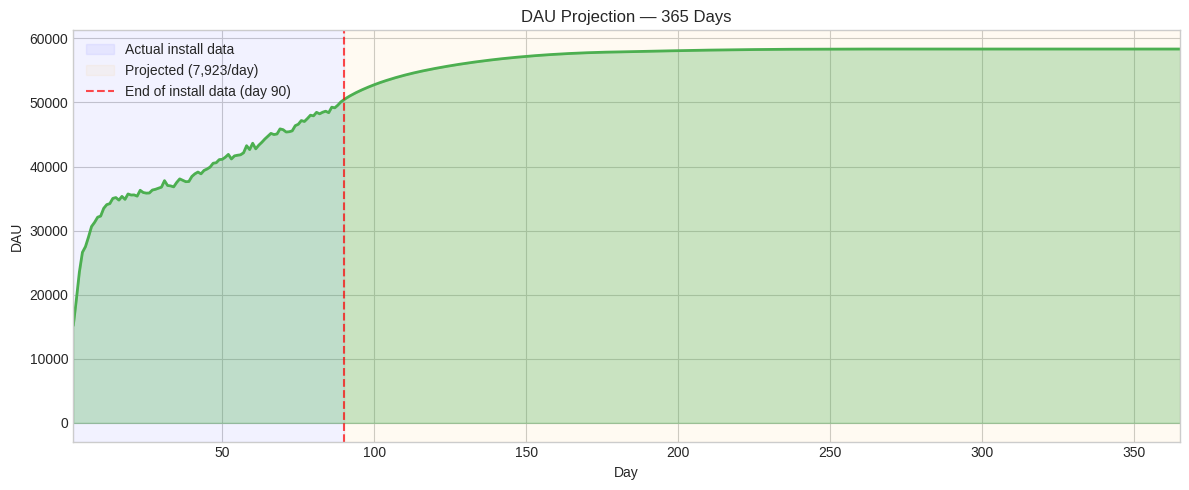

Install data: 90 days, last day = 90
Projected at 7,923/day from day 91 to 365
Steady-state DAU (Day 365): 58,344


In [4]:
# Extend installs at the last observed rate for a full year
last_day = int(installs.index[-1])
last_rate = int(installs.iloc[-1])
proj_days = 365

# Build extended install series: actual data + projected flat rate
extended_values = list(installs.values)
for d in range(last_day + 1, proj_days + 1):
    extended_values.append(last_rate)
extended = pd.Series(
    extended_values,
    index=np.arange(1, proj_days + 1),
    name='installs'
)
extended.index.name = 'day'

sim_365 = simulate(extended, cfg.retention, sim_days=proj_days)
result_365 = sim_365.to_dataframe()

fig, ax = plt.subplots(figsize=(12, 5))

# Shade actual vs projected regions
ax.axvspan(1, last_day, alpha=0.05, color='blue', label='Actual install data')
ax.axvspan(last_day, proj_days, alpha=0.05, color='orange', label=f'Projected ({last_rate:,}/day)')

ax.fill_between(result_365['day'], result_365['dau'], alpha=0.3, color='#4CAF50')
ax.plot(result_365['day'], result_365['dau'], linewidth=2, color='#4CAF50')
ax.axvline(x=last_day, color='red', linestyle='--', alpha=0.7, label=f'End of install data (day {last_day})')
ax.set_xlabel('Day')
ax.set_ylabel('DAU')
ax.set_title('DAU Projection — 365 Days')
ax.set_xlim(1, proj_days)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Install data: {len(installs)} days, last day = {last_day}")
print(f"Projected at {last_rate:,}/day from day {last_day + 1} to {proj_days}")
print(f"Steady-state DAU (Day {proj_days}): {result_365.iloc[-1]['dau']:,}")

## 4. Retention Sensitivity

How does DAU change if D1 retention shifts?

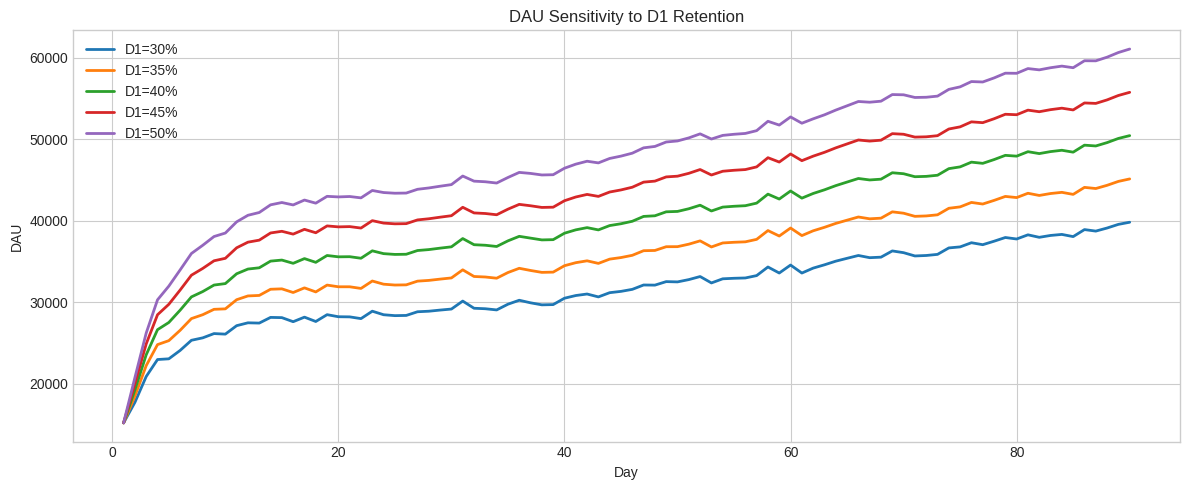

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

for d1 in [30, 35, 40, 45, 50]:
    curve_var = RetentionCurve(anchors=[
        (0, 100.0), (1, d1), (7, d1 * 0.5), (30, d1 * 0.125),
        (90, d1 * 0.025), (180, 0.0)
    ])
    r = simulate(installs, curve_var, sim_days=90).to_dataframe()
    ax.plot(r['day'], r['dau'], linewidth=2, label=f'D1={d1}%')

ax.set_xlabel('Day')
ax.set_ylabel('DAU')
ax.set_title('DAU Sensitivity to D1 Retention')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Cohort Heatmap

Retained users by cohort over time.

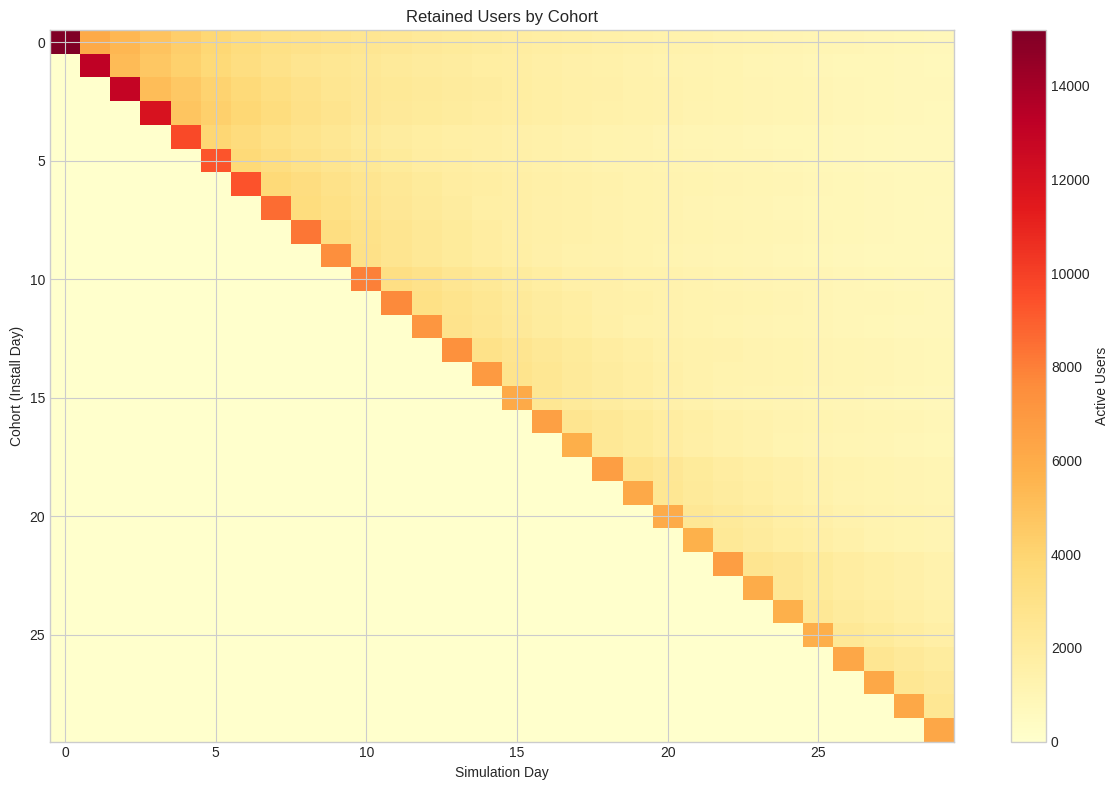

In [6]:
# Use the cohort matrix from the simulation (first 30 cohorts x 30 days)
n_show = 30
sim_heatmap = simulate(installs.iloc[:n_show], cfg.retention, sim_days=n_show)
cdf = sim_heatmap.cohort_dataframe()

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(cdf.values, aspect='auto', cmap='YlOrRd')
ax.set_xlabel('Simulation Day')
ax.set_ylabel('Cohort (Install Day)')
ax.set_title('Retained Users by Cohort')
plt.colorbar(im, ax=ax, label='Active Users')
plt.tight_layout()
plt.show()